In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv("titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.

#### X-axis: Embarked
#### Y-axis: Average of Survived
#### Add proper title and labels.
#### Identify which port has the highest survival rate.

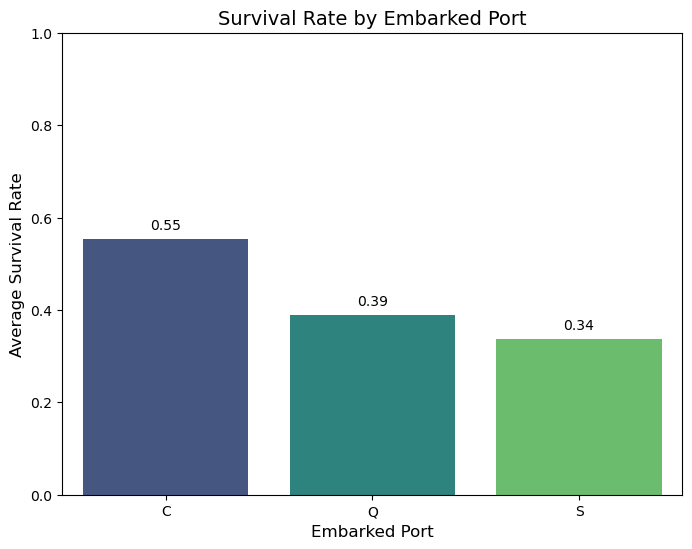

Q1: The port with the highest survival rate is 'C'.


In [10]:
embarked_survival = df.groupby('Embarked')['Survived'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=embarked_survival, x='Embarked', y='Survived', palette='viridis')
plt.title('Survival Rate by Embarked Port', fontsize=14)
plt.xlabel('Embarked Port', fontsize=12)
plt.ylabel('Average Survival Rate', fontsize=12)
plt.ylim(0, 1)
for i, v in enumerate(embarked_survival['Survived']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
plt.show()

highest_port = embarked_survival.loc[embarked_survival['Survived'].idxmax(), 'Embarked']
print(f"Q1: The port with the highest survival rate is '{highest_port}'.")

### Q2. Create a new column FamilySize using:

#### FamilySize = SibSp + Parch + 1

#### Then create a Count Plot showing the number of passengers for each family-size category.

#### X-axis: FamilySize
#### Y-axis: Number of Passengers
#### Identify the most common family size.

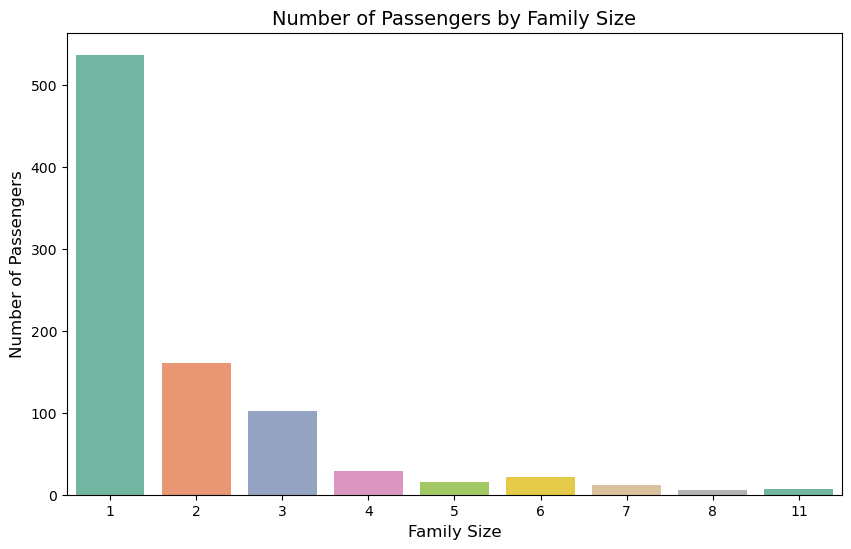

Q2: The most common family size is 1.


In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='FamilySize', palette='Set2')
plt.title('Number of Passengers by Family Size', fontsize=14)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.show()

most_common_size = df['FamilySize'].mode()[0]
print(f"Q2: The most common family size is {most_common_size}.")

### Q3. Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

#### X-axis: Pclass
#### Y-axis: Fare
#### Use Sex as hue.
#### Identify which group paid the highest fares.

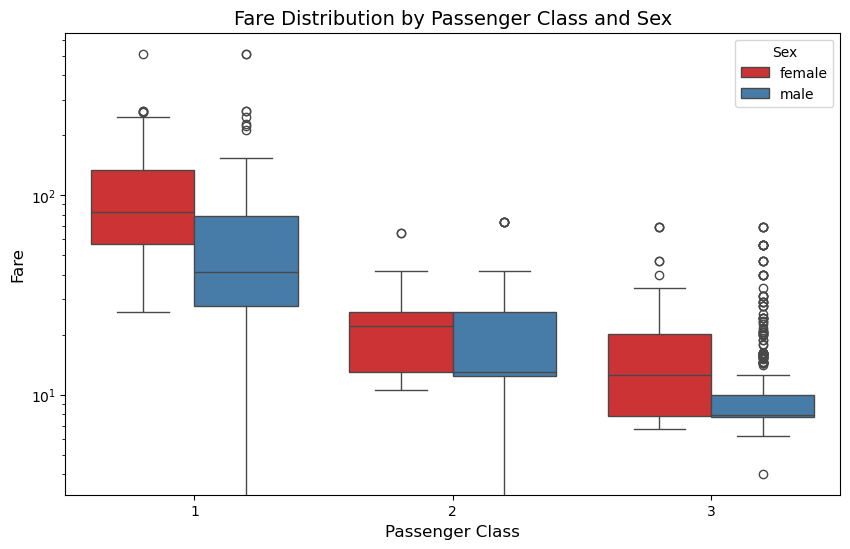

Q3: The group with the highest fare is (np.int64(1), 'female').


In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Sex', palette='Set1')
plt.title('Fare Distribution by Passenger Class and Sex', fontsize=14)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.legend(title='Sex')
plt.yscale('log')  
plt.show()

highest_fare_group = df.groupby(['Pclass', 'Sex'])['Fare'].max().idxmax()
print(f"Q3: The group with the highest fare is {highest_fare_group}.")

### Q4. Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

#### X-axis: FamilySize
#### Y-axis: Survival Rate
#### Add markers to the line.
#### Identify the family size with the highest survival rate.

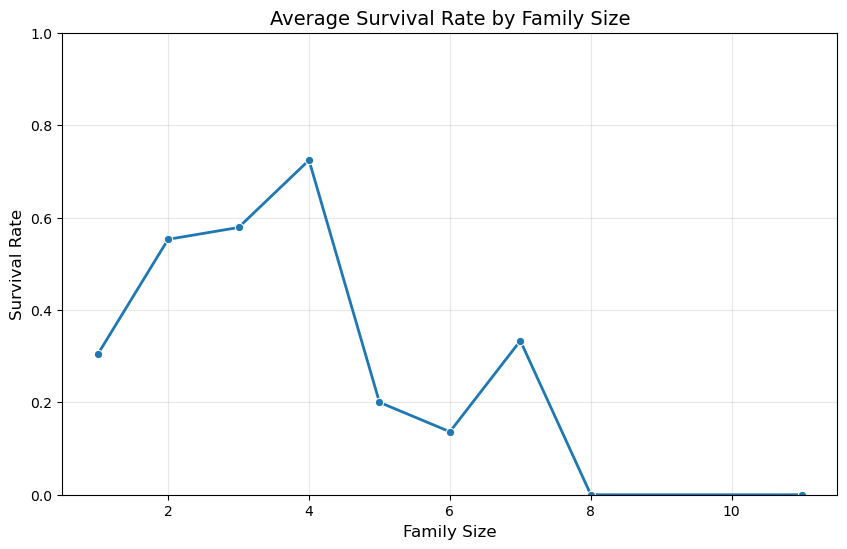

Q4: The family size with the highest survival rate is 4.


In [16]:
family_survival = df.groupby('FamilySize')['Survived'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=family_survival, x='FamilySize', y='Survived', marker='o', linewidth=2)
plt.title('Average Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Survival Rate', fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

highest_family_size = family_survival.loc[family_survival['Survived'].idxmax(), 'FamilySize']
print(f"Q4: The family size with the highest survival rate is {int(highest_family_size)}.")

### Q5.Passenger Class & Gender Survival Comparison
#### Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

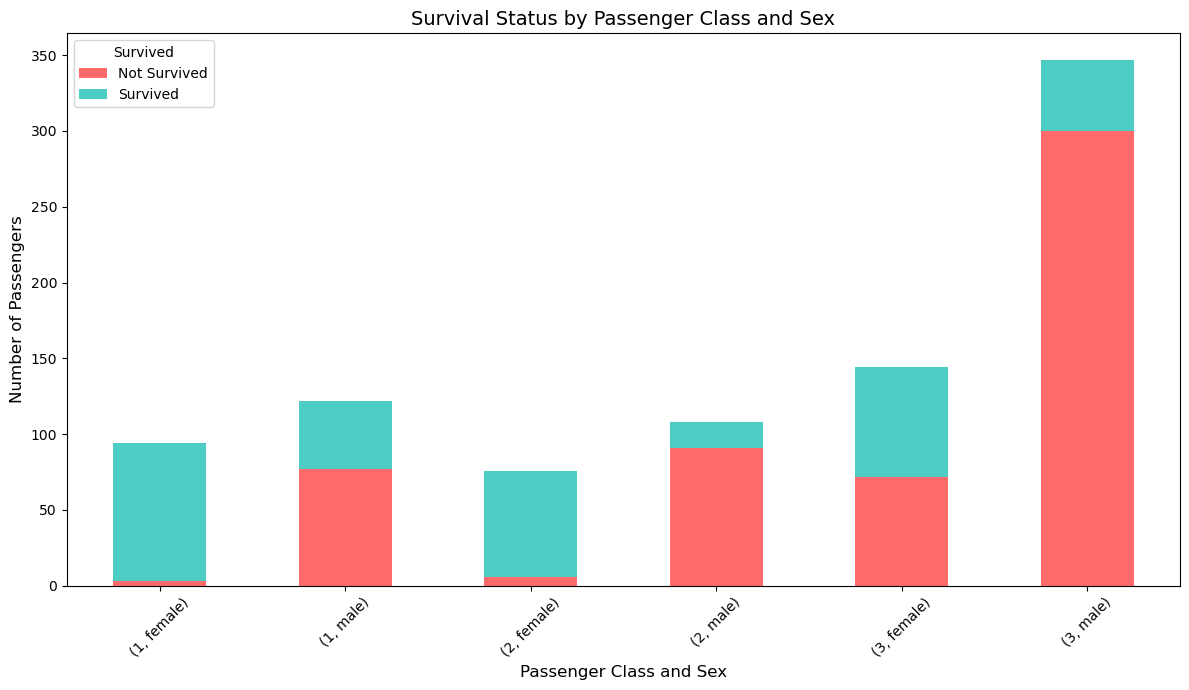

Q5: Survival counts by Pclass and Sex:
Survived         0   1
Pclass Sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47


In [18]:
pivot_table = pd.crosstab([df['Pclass'], df['Sex']], df['Survived'])

pivot_table.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#FF6B6B', '#4ECDC4'])
plt.title('Survival Status by Passenger Class and Sex', fontsize=14)
plt.xlabel('Passenger Class and Sex', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(title='Survived', labels=['Not Survived', 'Survived'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Q5: Survival counts by Pclass and Sex:")
print(pivot_table)